# Student Academic Risk Prediction

Using the Student Performance data set, predict whether a student is at risk (`G3 < 10`). The primary concern is missing an ‘at-risk’ student, thus recall has been chosen as the main indicator.

In [52]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_validate, train_test_split
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Load the dataset

In [53]:
# Set CSV_PATH to a local file, or leave it as None to use KaggleHub.
CSV_PATH = None  # Example: "data/student_data.csv"

if CSV_PATH:
    df = pd.read_csv(CSV_PATH)
else:
    import kagglehub

    dataset_path = Path(kagglehub.dataset_download(
        "devansodariya/student-performance-data"
    ))
    csv_files = list(dataset_path.rglob("*.csv"))
    if len(csv_files) != 1:
        raise FileNotFoundError(f"Expected one CSV, found: {csv_files}")
    df = pd.read_csv(csv_files[0])
    print(f"Loaded: {csv_files[0]}")

required = {"G1", "G2", "G3"}
if missing := required - set(df.columns):
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df.head()

Loaded: /Users/bklcross/.cache/kagglehub/datasets/devansodariya/student-performance-data/versions/1/student_data.csv


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Explore the data and create the target

In [54]:
print(f"Rows: {len(df)}, columns: {len(df.columns)}")
display(df.dtypes.rename("data type").to_frame())
display(df.isna().sum().rename("missing values").to_frame())
display(df[["G1", "G2", "G3"]].describe())

df["at_risk"] = (df["G3"] < 10).astype(int)
class_balance = df["at_risk"].map({0: "not at risk", 1: "at risk"}).value_counts()
display(class_balance.rename("students").to_frame())

Rows: 395, columns: 33


,data type
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


,missing values
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


,G1,G2,G3
count,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190
std,3.319195,3.761505,4.581443
min,3.000000,0.000000,0.000000
25%,8.000000,9.000000,8.000000
50%,11.000000,11.000000,11.000000
75%,13.000000,13.000000,14.000000
max,19.000000,19.000000,20.000000


,students
at_risk,
not at risk,265
at risk,130


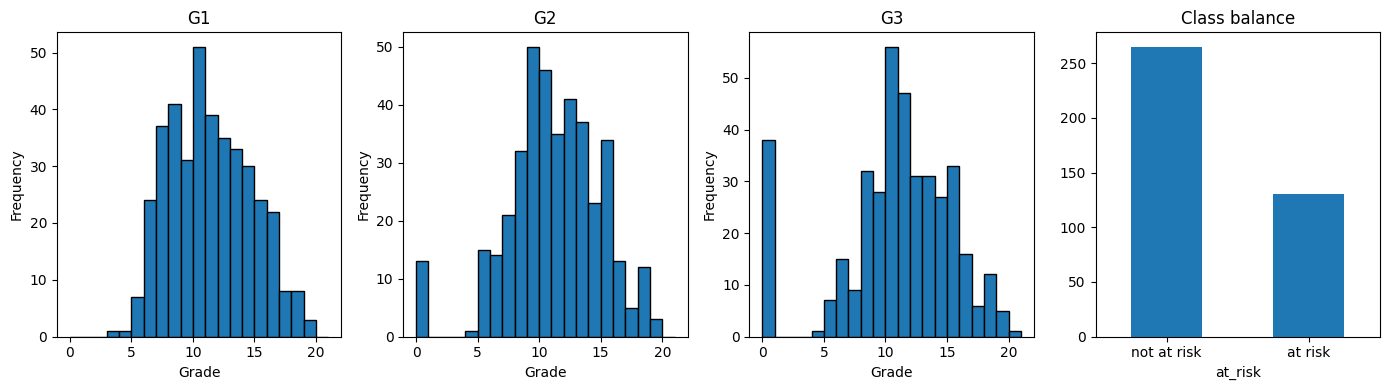

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, grade in zip(axes[:3], ["G1", "G2", "G3"]):
    df[grade].plot.hist(ax=ax, bins=range(22), edgecolor="black", title=grade)
    ax.set_xlabel("Grade")
class_balance.plot.bar(ax=axes[3], title="Class balance", rot=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_overview.png", dpi=150)
plt.show()

## Prepare feature sets and models

In [56]:
y = df["at_risk"]
X_full = df.drop(columns=["G3", "at_risk"])
feature_sets = {
    "Includes G1/G2": X_full,
    "Excludes G1/G2": X_full.drop(columns=["G1", "G2"]),
}

models = {
    "Baseline (majority)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

## Train and compare models

In [57]:
results, fitted = [], {}

for feature_name, X in feature_sets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    numeric = X.select_dtypes(include="number").columns
    categorical = X.select_dtypes(exclude="number").columns
    preprocessor = ColumnTransformer([
        ("numeric", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
        ("categorical", make_pipeline(
            SimpleImputer(strategy="most_frequent"),
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ), categorical),
    ])

    for model_name, model in models.items():
        pipeline = make_pipeline(preprocessor, clone(model))
        pipeline.fit(X_train, y_train)
        prediction = pipeline.predict(X_test)
        results.append({
            "feature_set": feature_name,
            "model": model_name,
            "accuracy": accuracy_score(y_test, prediction),
            "precision": precision_score(y_test, prediction, zero_division=0),
            "recall": recall_score(y_test, prediction, zero_division=0),
            "f1": f1_score(y_test, prediction, zero_division=0),
        })
        fitted[(feature_name, model_name)] = (pipeline, y_test, prediction)

results = pd.DataFrame(results).sort_values(["recall", "f1"], ascending=False)
results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)
results

,feature_set,model,accuracy,precision,recall,f1
3,Includes G1/G2,Random Forest,0.909091,0.852941,0.878788,0.865672
4,Includes G1/G2,Gradient Boosting,0.909091,0.852941,0.878788,0.865672
2,Includes G1/G2,Decision Tree,0.888889,0.805556,0.878788,0.840580
1,Includes G1/G2,Logistic Regression,0.868687,0.763158,0.878788,0.816901
6,Excludes G1/G2,Logistic Regression,0.666667,0.500000,0.545455,0.521739
7,Excludes G1/G2,Decision Tree,0.616162,0.428571,0.454545,0.441176
9,Excludes G1/G2,Gradient Boosting,0.686869,0.555556,0.303030,0.392157
8,Excludes G1/G2,Random Forest,0.686869,0.600000,0.181818,0.279070
0,Includes G1/G2,Baseline (majority),0.666667,0.000000,0.000000,0.000000
5,Excludes G1/G2,Baseline (majority),0.666667,0.000000,0.000000,0.000000


## Evaluate the best model

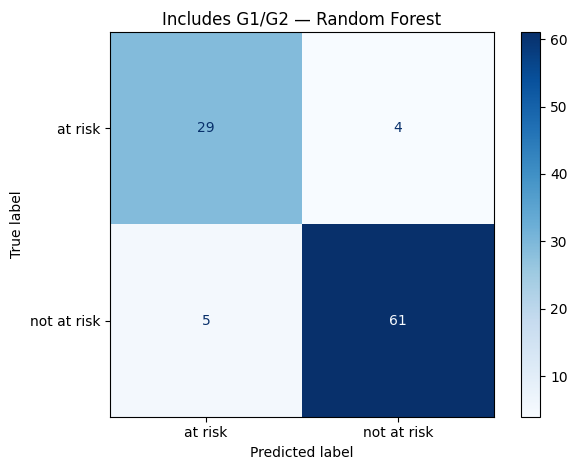

feature_set    Includes G1/G2
model           Random Forest
accuracy             0.909091
precision            0.852941
recall               0.878788
f1                   0.865672
Name: 3, dtype: object

In [58]:
# Highest recall wins; F1 breaks ties.
best = results.iloc[0]
pipeline, y_test, prediction = fitted[(best["feature_set"], best["model"])]

ConfusionMatrixDisplay.from_predictions(
    y_test, prediction, labels=[1, 0],
    display_labels=["at risk", "not at risk"], cmap="Blues"
)
plt.title(f"{best['feature_set']} — {best['model']}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()
best

## Important predictive features

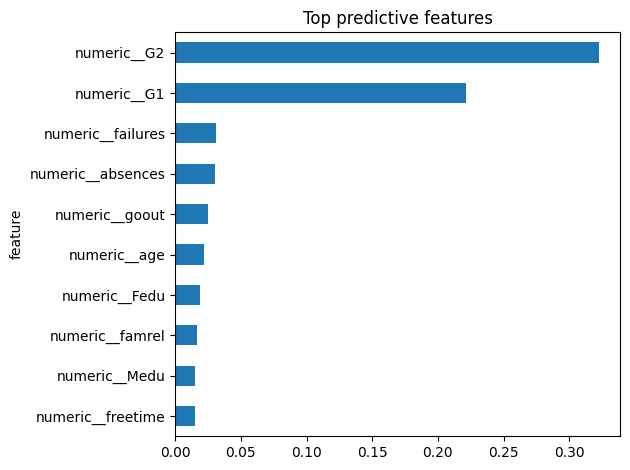

,feature,importance
14,numeric__G2,0.322461
13,numeric__G1,0.221388
5,numeric__failures,0.031213
12,numeric__absences,0.030012
8,numeric__goout,0.024873
0,numeric__age,0.021663
2,numeric__Fedu,0.019118
6,numeric__famrel,0.016969
1,numeric__Medu,0.015281
7,numeric__freetime,0.015013


In [59]:
preprocessor, model = pipeline.steps[0][1], pipeline.steps[1][1]
feature_names = preprocessor.get_feature_names_out()
values = (
    model.feature_importances_ if hasattr(model, "feature_importances_")
    else np.abs(model.coef_[0])
)
importance = pd.DataFrame({"feature": feature_names, "importance": values})
importance = importance.sort_values("importance", ascending=False)
importance.to_csv(OUTPUT_DIR / "feature_importance.csv", index=False)

importance.head(10).iloc[::-1].plot.barh(
    x="feature", y="importance", legend=False, title="Top predictive features"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=150)
plt.show()
importance.head(10)

## Cross-validation setup

In [60]:
def build_pipeline(X, model):
    numeric = X.select_dtypes(include="number").columns
    categorical = X.select_dtypes(exclude="number").columns
    preprocessor = ColumnTransformer([
        ("numeric", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
        ("categorical", make_pipeline(
            SimpleImputer(strategy="most_frequent"),
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ), categorical),
    ])
    return make_pipeline(preprocessor, clone(model))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

## Limited hyperparameter tuning

The searches below use small grids and optimize recall for the at-risk class. The tuned models are then evaluated with five-fold cross-validation.

In [61]:
tuning_plan = {
    "Includes G1/G2": (
        models["Random Forest"],
        {
            "randomforestclassifier__n_estimators": [200, 300],
            "randomforestclassifier__max_depth": [None, 8],
            "randomforestclassifier__min_samples_leaf": [1, 3],
        },
    ),
    "Excludes G1/G2": (
        models["Logistic Regression"],
        {"logisticregression__C": [0.1, 1.0, 10.0]},
    ),
}

tuned = {}
tuning_rows = []
for feature_name, (model, grid) in tuning_plan.items():
    X = feature_sets[feature_name]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    search = GridSearchCV(
        build_pipeline(X, model), grid, scoring="recall", cv=cv, n_jobs=-1
    )
    search.fit(X_train, y_train)
    prediction = search.predict(X_test)
    row = {
        "feature_set": feature_name,
        "model": type(model).__name__,
        "accuracy": accuracy_score(y_test, prediction),
        "precision": precision_score(y_test, prediction, zero_division=0),
        "recall": recall_score(y_test, prediction, zero_division=0),
        "f1": f1_score(y_test, prediction, zero_division=0),
        "best_cv_recall": search.best_score_,
        "best_parameters": search.best_params_,
    }
    tuning_rows.append(row)
    tuned[feature_name] = (search.best_estimator_, X_test, y_test, prediction)

cv_rows = []
for feature_name, (pipeline, _, _, _) in tuned.items():
    scores = cross_validate(
        pipeline, feature_sets[feature_name], y, cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"],
    )
    row = {"feature_set": feature_name, "model": type(pipeline.steps[-1][1]).__name__}
    for metric in ["accuracy", "precision", "recall", "f1"]:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)
cv_results = pd.DataFrame(cv_rows)
cv_results.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)

tuning_results = pd.DataFrame(tuning_rows)
tuning_text = "\n\n".join(
    f"{row['feature_set']} — {row['model']}\n"
    f"Best parameters: {row['best_parameters']}\n"
    f"CV recall: {row['best_cv_recall']:.3f}\n"
    f"Test accuracy: {row['accuracy']:.3f}, precision: {row['precision']:.3f}, "
    f"recall: {row['recall']:.3f}, F1: {row['f1']:.3f}"
    for row in tuning_rows
)
(OUTPUT_DIR / "tuning_results.txt").write_text(tuning_text)
display(tuning_results)
cv_results

,feature_set,model,accuracy,precision,recall,f1,best_cv_recall,best_parameters
0,Includes G1/G2,RandomForestClassifier,0.919192,0.857143,0.909091,0.882353,0.907895,"{'randomforestclassifier__max_depth': None, 'r..."
1,Excludes G1/G2,LogisticRegression,0.656566,0.485714,0.515152,0.500000,0.546842,{'logisticregression__C': 10.0}


,feature_set,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Includes G1/G2,RandomForestClassifier,0.908861,0.029306,0.827005,0.037946,0.915385,0.074580,0.867579,0.046975
1,Excludes G1/G2,LogisticRegression,0.650633,0.054651,0.477214,0.069868,0.569231,0.085658,0.517509,0.069328


## Final evaluation and subgroup check

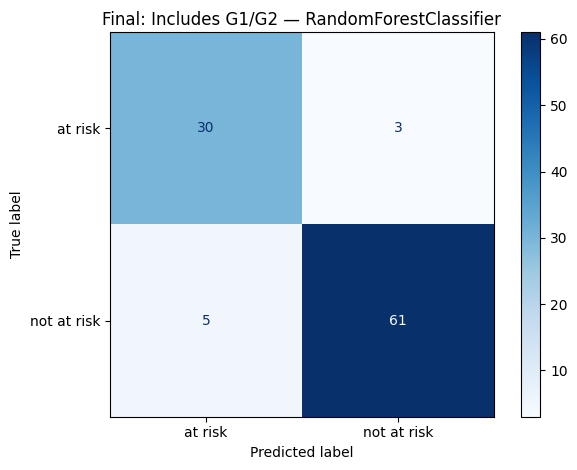

,feature_set,model,accuracy,precision,recall,f1,cv_recall_mean,cv_recall_std
0,Baseline comparison,Baseline (majority),0.666667,0.000000,0.000000,0.000000,NaN,NaN
1,Includes G1/G2,RandomForestClassifier,0.919192,0.857143,0.909091,0.882353,0.915385,0.074580
2,Excludes G1/G2,LogisticRegression,0.656566,0.485714,0.515152,0.500000,0.569231,0.085658


,sex,students,at_risk_students,recall
0,F,50,19,0.947368
1,M,49,14,0.857143


The subgroup samples are too small for strong fairness conclusions; these results do not establish that the model is fair.


In [62]:
baseline = results[results["model"] == "Baseline (majority)"].iloc[0]
baseline_row = {
    "feature_set": "Baseline comparison",
    "model": baseline["model"],
    "accuracy": baseline["accuracy"],
    "precision": baseline["precision"],
    "recall": baseline["recall"],
    "f1": baseline["f1"],
    "cv_recall_mean": np.nan,
    "cv_recall_std": np.nan,
}
final_rows = [baseline_row]
for row in tuning_rows:
    cv_row = cv_results[cv_results["feature_set"] == row["feature_set"]].iloc[0]
    final_rows.append({
        "feature_set": row["feature_set"],
        "model": row["model"],
        "accuracy": row["accuracy"],
        "precision": row["precision"],
        "recall": row["recall"],
        "f1": row["f1"],
        "cv_recall_mean": cv_row["recall_mean"],
        "cv_recall_std": cv_row["recall_std"],
    })
final_results = pd.DataFrame(final_rows)
final_results.to_csv(OUTPUT_DIR / "final_model_results.csv", index=False)

best_final = tuning_results.sort_values(["recall", "f1"], ascending=False).iloc[0]
final_pipeline, X_test, y_test, prediction = tuned[best_final["feature_set"]]
ConfusionMatrixDisplay.from_predictions(
    y_test, prediction, labels=[1, 0],
    display_labels=["at risk", "not at risk"], cmap="Blues"
)
plt.title(f"Final: {best_final['feature_set']} — {best_final['model']}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_confusion_matrix.png", dpi=150)
plt.show()

subgroup_rows = []
test_sex = df.loc[X_test.index, "sex"]
for sex in sorted(test_sex.unique()):
    mask = test_sex == sex
    subgroup_rows.append({
        "sex": sex,
        "students": int(mask.sum()),
        "at_risk_students": int(y_test[mask].sum()),
        "recall": recall_score(y_test[mask], prediction[mask], zero_division=0),
    })
subgroup_results = pd.DataFrame(subgroup_rows)
subgroup_results.to_csv(OUTPUT_DIR / "subgroup_results.csv", index=False)
display(final_results)
display(subgroup_results)
print("The subgroup samples are too small for strong fairness conclusions; these results do not establish that the model is fair.")

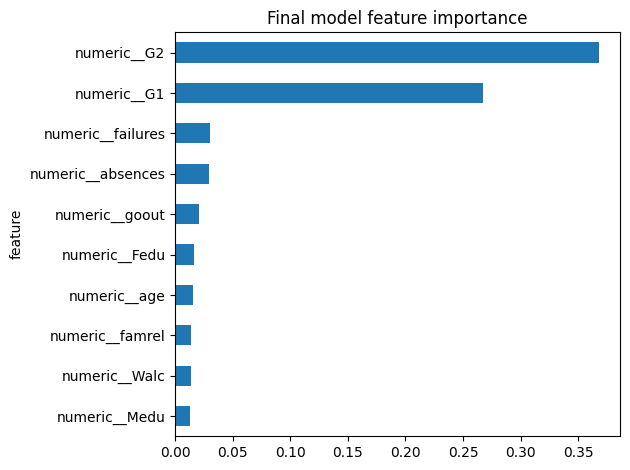

Final Summary
=============
Best model with G1/G2: RandomForestClassifier (recall 0.909, CV recall 0.915 ± 0.075).
Best model without G1/G2: LogisticRegression (recall 0.515, CV recall 0.569 ± 0.086).
The majority-class baseline had recall 0.000 for at-risk students.

Cross-validation gives a more stable estimate than one train/test split. Removing G1 and G2 reduced recall, showing that useful early prediction is more difficult without prior grades. Predictive features show associations, not causes.

The main limitation is the small dataset from a limited student population. Model families were also chosen after the initial split comparison. The sex subgroup samples are too small for strong fairness conclusions, and the results do not show that the model is fair.

This model is intended to support students and human decision-making, not to label, punish, or automatically make decisions about them. Future work should test more populations, assess fairness, and validate performance over time.


In [63]:
final_preprocessor = final_pipeline.steps[0][1]
final_model = final_pipeline.steps[1][1]
feature_names = final_preprocessor.get_feature_names_out()
values = (
    final_model.feature_importances_ if hasattr(final_model, "feature_importances_")
    else np.abs(final_model.coef_[0])
)
final_importance = pd.DataFrame({"feature": feature_names, "importance": values})
final_importance = final_importance.sort_values("importance", ascending=False)
final_importance.head(10).iloc[::-1].plot.barh(
    x="feature", y="importance", legend=False, title="Final model feature importance"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_feature_importance.png", dpi=150)
plt.show()

full = final_results[final_results["feature_set"] == "Includes G1/G2"].iloc[0]
early = final_results[final_results["feature_set"] == "Excludes G1/G2"].iloc[0]
summary = f"""Final Summary
=============
Best model with G1/G2: {full['model']} (recall {full['recall']:.3f}, CV recall {full['cv_recall_mean']:.3f} ± {full['cv_recall_std']:.3f}).
Best model without G1/G2: {early['model']} (recall {early['recall']:.3f}, CV recall {early['cv_recall_mean']:.3f} ± {early['cv_recall_std']:.3f}).
The majority-class baseline had recall {baseline['recall']:.3f} for at-risk students.

Cross-validation gives a more stable estimate than one train/test split. Removing G1 and G2 reduced recall, showing that useful early prediction is more difficult without prior grades. Predictive features show associations, not causes.

The main limitation is the small dataset from a limited student population. Model families were also chosen after the initial split comparison. The sex subgroup samples are too small for strong fairness conclusions, and the results do not show that the model is fair.

This model is intended to support students and human decision-making, not to label, punish, or automatically make decisions about them. Future work should test more populations, assess fairness, and validate performance over time.
"""
(OUTPUT_DIR / "final_summary.txt").write_text(summary)
display(Markdown(summary))

## Conclusion

The full-feature model is expected to perform better because G1 and G2 contain recent academic information. Removing them makes earlier intervention possible but reduces predictive performance. Cross-validation and limited tuning provide more reliable estimates than a single split.

The dataset is small, model families were chosen after the initial split comparison, and subgroup results cannot support strong fairness conclusions. Feature importance describes association rather than causation. The model should be used only to support students and informed human review—not to label, punish, or automatically make decisions about them. Future work should validate the approach with larger and more diverse student populations.